In [110]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *
from LoadTSV import *

In [111]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [112]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1))]

# Some first plots

In [113]:
# Parameter
M = 4
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 10
polydeg = 1
rho_L = 7.0
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0
# name = f"../out/1D3D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}"
anglepair = 0 # default angle
name = f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}"

/tmp/ipykernel_16641/2498118703.py:24: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


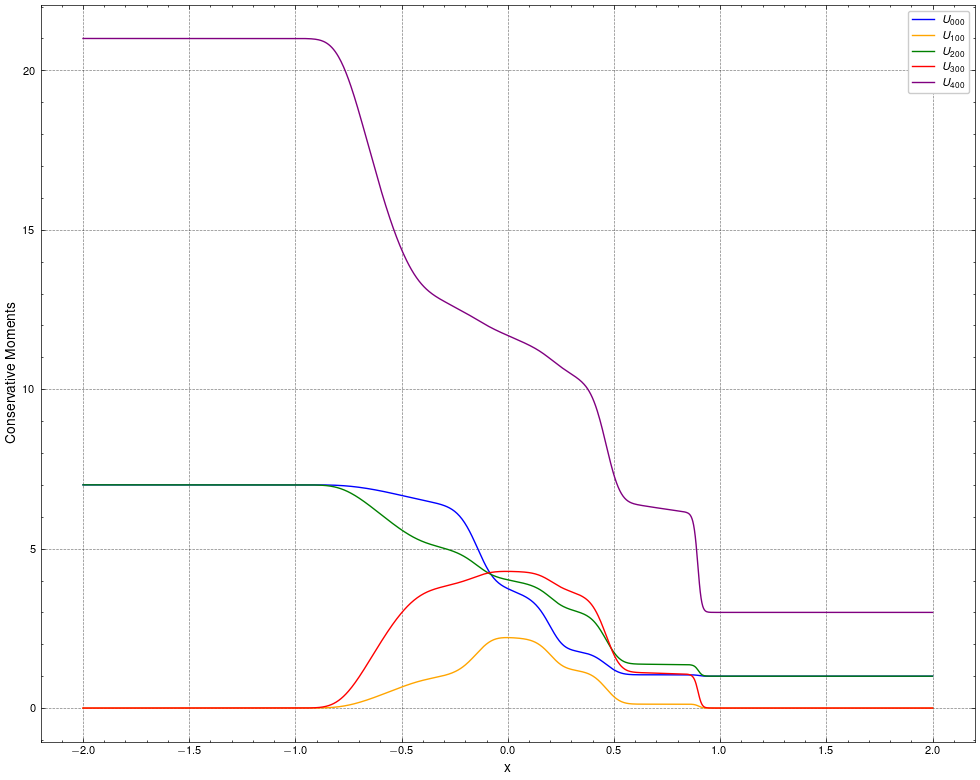

In [114]:
# Conservative Moments
data = read_solution_file(name + "_cons.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, U[:, 0], label="$U_{000}$", color=colors[0])
axs.plot(x, U[:, 1], label="$U_{100}$", color=colors[1])
axs.plot(x, U[:, 2], label="$U_{200}$", color=colors[2])
axs.plot(x, U[:, 4], label="$U_{300}$", color=colors[3])
axs.plot(x, U[:, 6], label="$U_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Conservative Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments.pdf')
fig.show()

/tmp/ipykernel_16641/1207176404.py:26: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


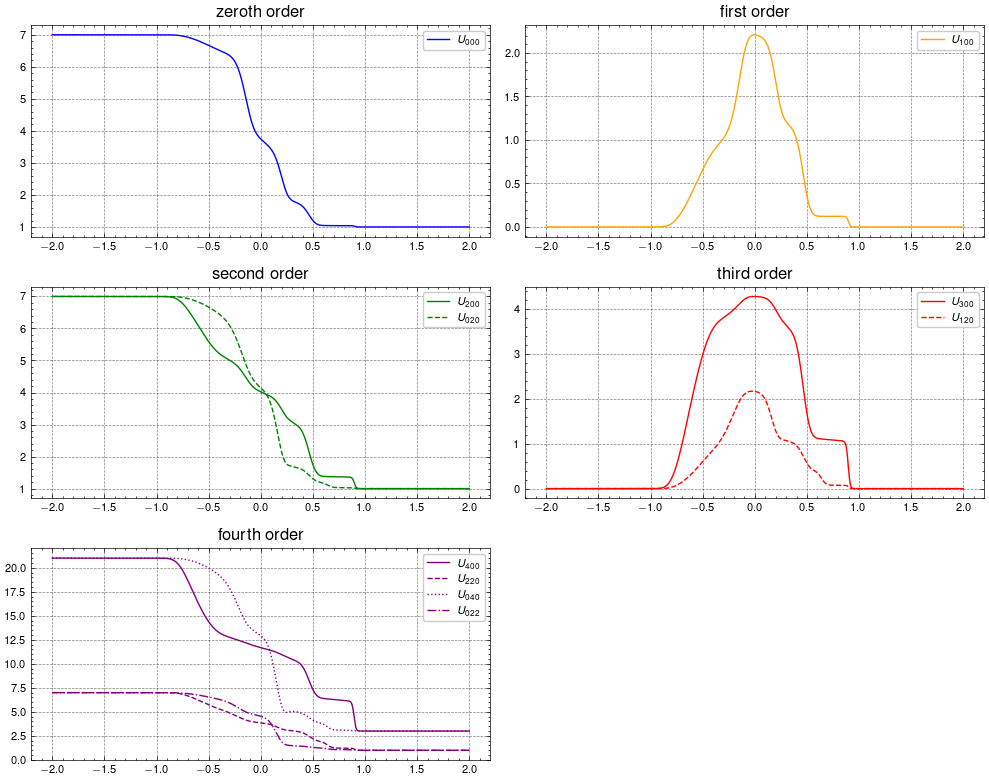

In [115]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, U[:, 0], label="$U_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, U[:, 1], label="$U_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, U[:, 2], label="$U_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, U[:, 3], label="$U_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, U[:, 4], label="$U_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, U[:, 5], label="$U_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, U[:, 6], label="$U_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, U[:, 7], label="$U_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, U[:, 8], label="$U_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, U[:, 9], label="$U_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments_Full.pdf')
fig.show()

/tmp/ipykernel_16641/1518321668.py:24: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


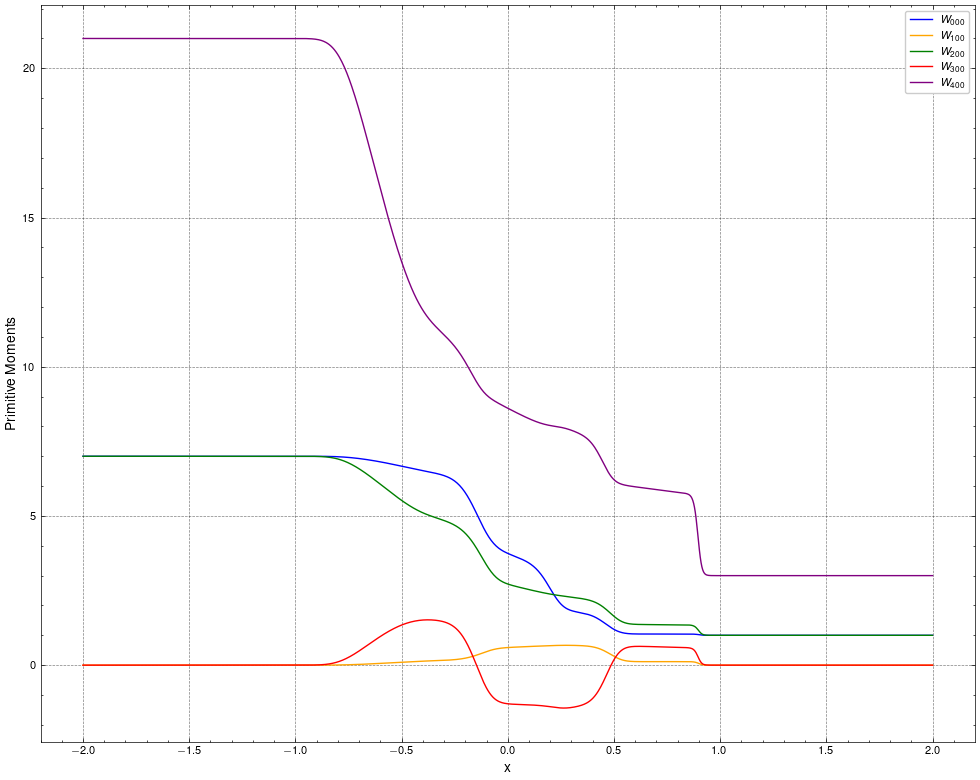

In [116]:
# Primitive Moments
data = read_solution_file(name + "_prim.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, W, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, W[:, 0], label="$W_{000}$", color=colors[0])
axs.plot(x, W[:, 1], label="$W_{100}$", color=colors[1])
axs.plot(x, W[:, 2], label="$W_{200}$", color=colors[2])
axs.plot(x, W[:, 4], label="$W_{300}$", color=colors[3])
axs.plot(x, W[:, 6], label="$W_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Primitive Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments.pdf')
fig.show()

/tmp/ipykernel_16641/2880951885.py:26: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


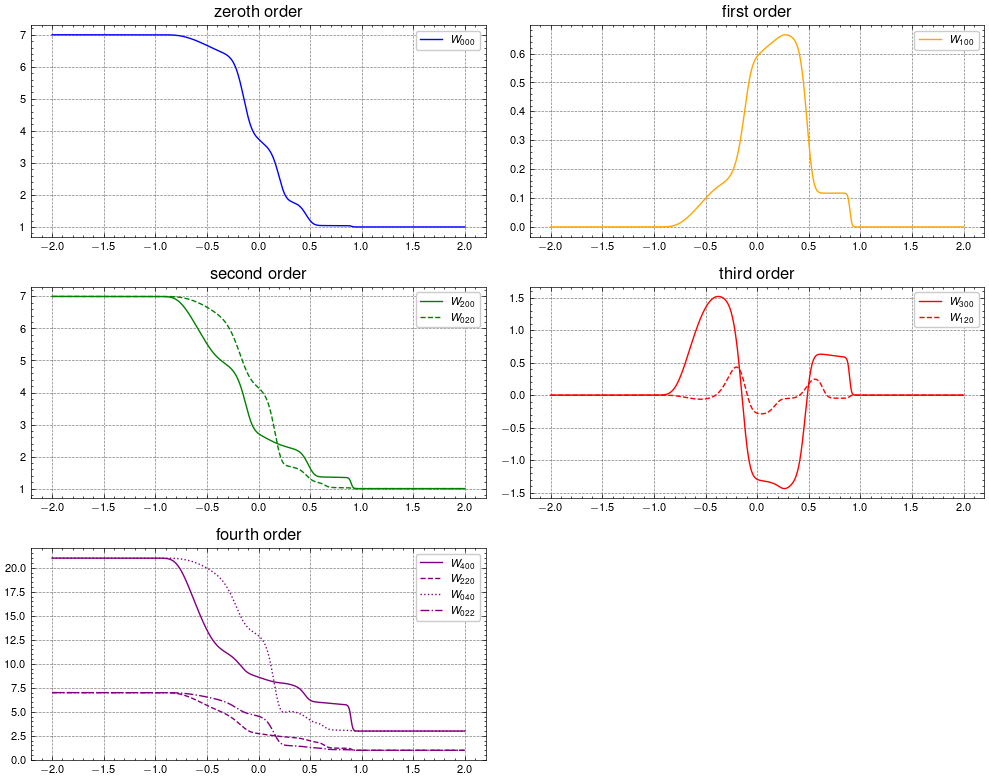

In [117]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, W[:, 0], label="$W_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, W[:, 1], label="$W_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, W[:, 2], label="$W_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, W[:, 3], label="$W_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, W[:, 4], label="$W_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, W[:, 5], label="$W_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, W[:, 6], label="$W_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, W[:, 7], label="$W_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, W[:, 8], label="$W_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, W[:, 9], label="$W_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments_Full.pdf')
fig.show()

## Compare 1D1D with 1D3D

In [118]:
source = "relaxation_source"
v_L = v_L1
v_R = v_R1
file_1D1D = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x_1D1D, u_1D1D, _ = sol_final(file_1D1D)

/tmp/ipykernel_16641/3300311430.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


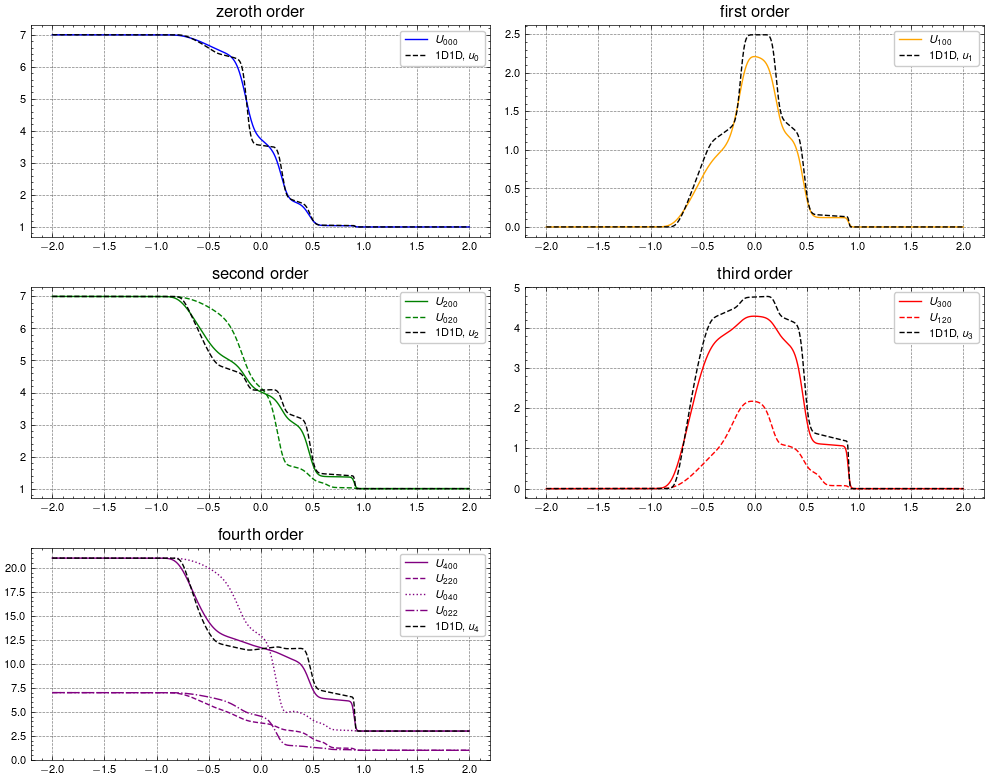

In [119]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, U[:, 0], label="$U_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].plot(x_1D1D, u_1D1D[:, 0], label="1D1D, $u_{0}$", color='black', linestyle='dashed')
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, U[:, 1], label="$U_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].plot(x_1D1D, u_1D1D[:, 1], label="1D1D, $u_{1}$", color='black', linestyle='dashed')
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, U[:, 2], label="$U_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, U[:, 3], label="$U_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].plot(x_1D1D, u_1D1D[:, 2], label="1D1D, $u_{2}$", color='black', linestyle='dashed')
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, U[:, 4], label="$U_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, U[:, 5], label="$U_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].plot(x_1D1D, u_1D1D[:, 3], label="1D1D, $u_{3}$", color='black', linestyle='dashed')
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, U[:, 6], label="$U_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, U[:, 7], label="$U_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, U[:, 8], label="$U_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, U[:, 9], label="$U_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].plot(x_1D1D, u_1D1D[:, 4], label="1D1D, $u_{4}$", color='black', linestyle='dashed')
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments_Full.pdf')
fig.show()

# Different angle pairs

In [120]:
closure = 'ExtGram'
Kn = 1.0
T_end = 0.3
n_angle_pairs = 4
name = lambda anglepair: f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}_cons.tsv"

marker = ['o', 's', '^', 'x', 'd']

Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber0_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber1_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber2_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber3_Tend0.3_cons.tsv


/tmp/ipykernel_16641/1933705014.py:32: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


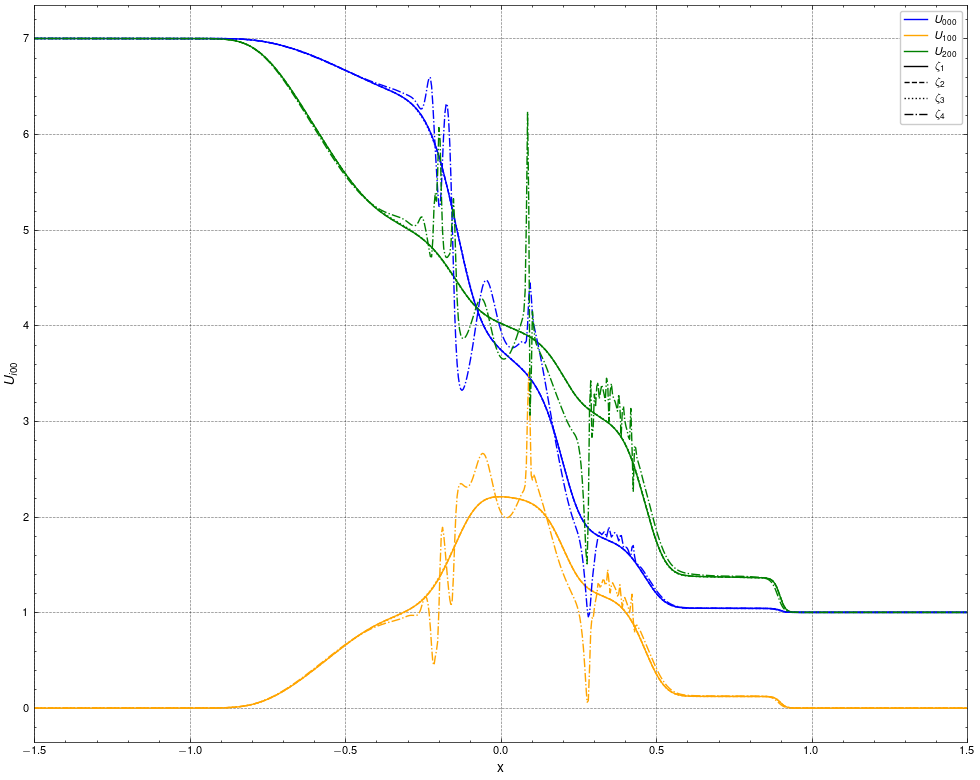

In [121]:
# Conservative Moments
fig, axs = plt.subplots(figsize=(10, 8))
names = [name(i) for i in range(n_angle_pairs)]
for i, solution_file in enumerate(names):

    data = read_solution_file(solution_file)
    print(f"Loaded data from {solution_file}")

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
    axs.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
    axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
    # axs.plot(x, U[:, 4], color=colors[3], linestyle=linestyles[i])
    # axs.plot(x, U[:, 6], color=colors[4], linestyle=linestyles[i])
labels = ['$U_{000}$', '$U_{100}$', '$U_{200}$']
[axs.plot([], [], color=colors[i], linestyle='-', label=label) for i, label in enumerate(labels)]
[axs.plot([], [], color='black', linestyle=linestyles[i], label=f'$\zeta_{i+1}$') for i in range(4)]
axs.set_xlabel("x")
axs.set_ylabel("$U_{i00}$")
axs.grid(True)
axs.legend()
axs.set_xlim(-1.5, 1.5)
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/CompareAnglePairs.pdf')
fig.show()

Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber0_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber1_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber2_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber3_Tend0.3_cons.tsv


/tmp/ipykernel_16641/3880646646.py:28: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


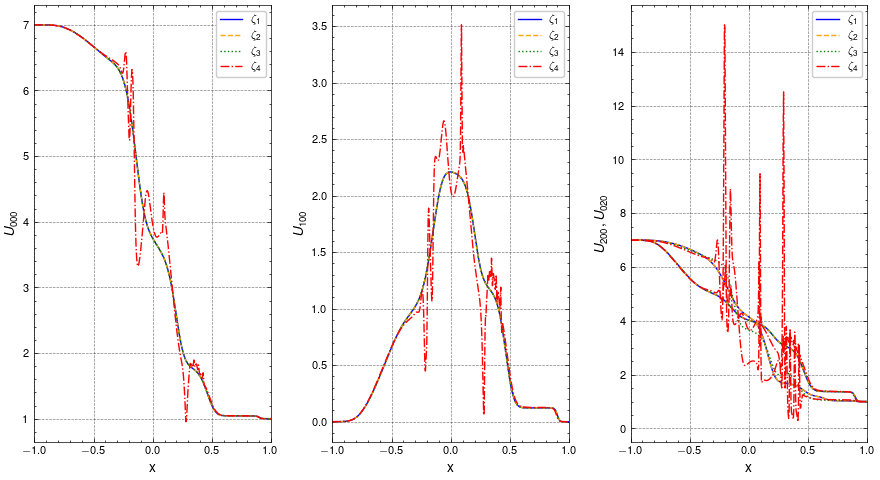

In [122]:
fig, axs = plt.subplots(1, 3)

[ax.set_xlim(-1, 1) for ax in axs]
[ax.set_xlabel('x') for ax in axs]
[ax.set_ylabel(label) for ax, label in zip(axs, ['$U_{000}$', '$U_{100}$', '$U_{200}, U_{020}$'])]

for i, solution_file in enumerate(names):

    data = read_solution_file(solution_file)
    print(f"Loaded data from {solution_file}")

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs[0].plot(x, U[:, 0], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
    axs[1].plot(x, U[:, 1], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
    axs[2].plot(x, U[:, 2], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
    axs[2].plot(x, U[:, 3], color=colors[i], linestyle=linestyles[i])

[ax.legend() for ax in axs]

fig.tight_layout()
fig.show()

Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber0_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber1_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber2_Tend0.3_cons.tsv


/tmp/ipykernel_16641/3953722731.py:47: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


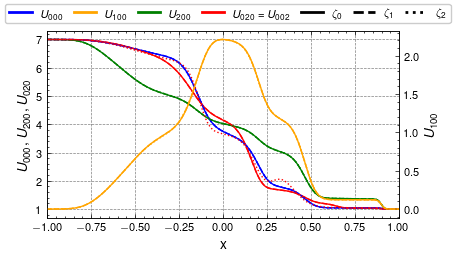

In [123]:
fig, axs = plt.subplots(figsize=(3/4*6.0, 2.5))
twx = axs.twinx()
twx.grid(False)

axs.set_xlim(-1, 1)
axs.set_xlabel('x')
axs.set_ylabel('$U_{000}$, $U_{200}, U_{020}$')
twx.set_ylabel('$U_{100}$')

for i in range(n_angle_pairs-1): # erase last angle pair, very bad solutions
    solution_file = names[i]

    data = read_solution_file(solution_file)
    print(f"Loaded data from {solution_file}")

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
    twx.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
    axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
    axs.plot(x, U[:, 3], color=colors[3], linestyle=linestyles[i])

elements = [
        Line2D([], [], color=colors[0], lw=2, label='$U_{000}$'),
        Line2D([], [], color=colors[1], lw=2, label='$U_{100}$'),
        Line2D([], [], color=colors[2], lw=2, label='$U_{200}$'),
        Line2D([], [], color=colors[3], lw=2, label='$U_{020}=U_{002}$'),
    ] + [Line2D([], [], color='black', linestyle=linestyles[i], lw=2, label=f'$\\zeta_{i}$') for i in range(n_angle_pairs-1)]

leg = fig.legend(
    handles=elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.07), 
    ncol=7, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig('../out/Figures/1D3D/AnglePairsCons.pdf')
fig.show()

Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber3_Tend0.3_cons.tsv


/tmp/ipykernel_16641/449171601.py:47: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


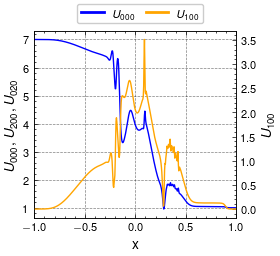

In [124]:
fig, axs = plt.subplots(figsize=(2/4*6.0, 2.5))
twx = axs.twinx()
twx.grid(False)

axs.set_xlim(-1, 1)
axs.set_xlabel('x')
axs.set_ylabel('$U_{000}$, $U_{200}, U_{020}$')
twx.set_ylabel('$U_{100}$')

# Last angle pair, to show its relevance
solution_file = names[-1]

data = read_solution_file(solution_file)
print(f"Loaded data from {solution_file}")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

axs.plot(x, U[:, 0], color=colors[0])
twx.plot(x, U[:, 1], color=colors[1])
# axs.plot(x, U[:, 2], color=colors[2])
# axs.plot(x, U[:, 3], color=colors[3])

elements = [
        Line2D([], [], color=colors[0], lw=2, label='$U_{000}$'),
        Line2D([], [], color=colors[1], lw=2, label='$U_{100}$'),
        # Line2D([], [], color=colors[2], lw=2, label='$U_{200}$'),
        # Line2D([], [], color=colors[3], lw=2, label='$U_{020}=U_{002}$'),
    ]

leg = fig.legend(
    handles=elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.07), 
    ncol=7, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig('../out/Figures/1D3D/AnglePairsCons_unstablepair.pdf')
fig.show()

In [125]:
Knudsen = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
name = lambda anglepair, Kn: f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}_cons.tsv"

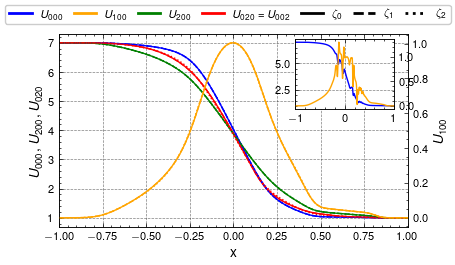

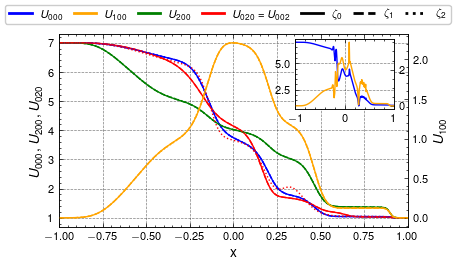

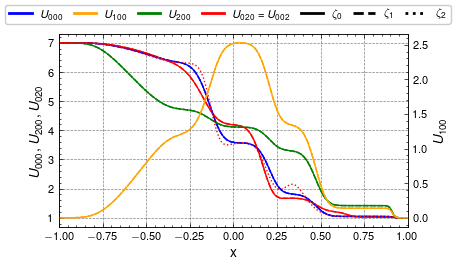

In [135]:
# Merging both
for Kn, source in zip(Knudsen, sources):
    fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))
    twx = axs.twinx()
    twx.grid(False)

    axs.set_xlim(-1, 1)
    axs.set_xlabel('x')
    axs.set_ylabel('$U_{000}$, $U_{200}, U_{020}$')
    twx.set_ylabel('$U_{100}$')

    # Stable angles
    for i in range(n_angle_pairs - 1):
        solution_file = name(i, Kn)
        data = read_solution_file(solution_file)
        
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))
        
        time_query = 21 
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, U = sol["x"], sol["u"]

        axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
        twx.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
        axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
        axs.plot(x, U[:, 3], color=colors[3], linestyle=linestyles[i])

    if source != 'zero_source': # skip, as diverged
        # Window for unstable pair
        # Coordinates: [left, bottom, width, height] in figure fractions (0 to 1)
        inset_pos = [0.65, 0.58, 0.22, 0.28] 
        axs_inset = fig.add_axes(inset_pos)
        twx_inset = axs_inset.twinx()
        twx_inset.grid(False)

        # Style
        axs_inset.set_xlim(-1, 1)
        axs_inset.tick_params(axis='both', which='major', labelsize=8)
        twx_inset.tick_params(axis='both', which='major', labelsize=8)
        # axs_inset.set_title("Unstable Pair", fontsize=9, pad=2)

        # Plot unstable pair
        sol_last = interpolate_solution(read_solution_file(name(n_angle_pairs - 1, Kn)), 21, times, timesteps)
        x_l, U_l = sol_last["x"], sol_last["u"]

        axs_inset.plot(x_l, U_l[:, 0], color=colors[0])
        twx_inset.plot(x_l, U_l[:, 1], color=colors[1])

    # Legend and Layout
    elements = [
        Line2D([], [], color=colors[0], lw=2, label='$U_{000}$'),
        Line2D([], [], color=colors[1], lw=2, label='$U_{100}$'),
        Line2D([], [], color=colors[2], lw=2, label='$U_{200}$'),
        Line2D([], [], color=colors[3], lw=2, label='$U_{020}=U_{002}$'),
    ] + [Line2D([], [], color='black', linestyle=linestyles[i], lw=2, label=f'$\\zeta_{i}$') for i in range(n_angle_pairs-1)]

    fig.legend(
        handles=elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.02), # Increased to make room for the window
        ncol=7, 
        columnspacing=1.0 
    )

    # Note: tight_layout often crushes manual insets, so we use it carefully or skip it
    # fig.tight_layout() 
    fig.savefig(f'../out/Figures/1D3D/Merged_AnglePairs_Kn{Kn}_source_{source}.pdf', bbox_inches='tight')
    plt.show()

Eigenvalues: [-2.4494897427831615, -1.4491376746152849, -1.000000000000021, -3.1271773120057808e-18, 4.180797309444589e-17, 5.191904773689105e-17, 5.191904773689105e-17, 1.0000000000000218, 1.4491376746152835, 2.4494897427831646]
Eigenvalues: [-2.4494897427831606, -1.4491376746159772, -1.0000000000000215, -3.127177163410926e-18, 1.549500494069767e-17, 5.4534066445480894e-17, 7.68670896318301e-17, 1.000000000000023, 1.4491376746159783, 2.4494897427831646]
Eigenvalues: [-2.449489731322743, -1.0036390780448052, -0.9999994660518089, -2.357777595550689e-17, -3.1271624105464864e-18, 6.513130129525212e-17, 1.3865597731948905e-16, 0.9999994660518048, 1.0036390780448108, 2.4494897313227484]
Eigenvalues: [-2.4494908727414915, -0.9999997661467491, -1.6653345369377348e-16, -1.6653345369377348e-16, -2.3006231889766145e-17, -2.3006231889766145e-17, -2.4982161875310668e-18, 5.49965915804809e-17, 0.9999997661467481, 2.4494908727414995]


/tmp/ipykernel_16641/4087826162.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Eigenvalues: [-2.4494897427831597, -1.4491376746152866, -1.0000000000000224, -6.027813052271229e-18, 1.7479580489172846e-17, 3.754250012103627e-17, 5.697580067419013e-17, 1.000000000000022, 1.4491376746152858, 2.4494897427831623]
Eigenvalues: [-2.449489742783163, -1.4491376746159774, -1.0000000000000224, -6.027812972963575e-18, 1.2586255810959082e-17, 5.0859198298326397e-17, 7.351429663343154e-17, 1.0000000000000224, 1.4491376746159788, 2.4494897427831646]
Eigenvalues: [-2.4494897313227417, -1.0036390780448128, -0.9999994660518063, -6.027811285627202e-18, 6.203448442671765e-17, 1.1448590337180427e-16, 1.1448590337180427e-16, 0.9999994660518079, 1.0036390780448086, 2.449489731322748]
Eigenvalues: [-2.449490872741498, -0.9999997661467456, -1.2098199703351574e-16, -6.243131867861777e-18, 5.263027318067975e-17, 1.8778069665943076e-16, 3.3306690738754696e-16, 3.3306690738754696e-16, 0.9999997661467461, 2.449490872741499]


/tmp/ipykernel_16641/4087826162.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


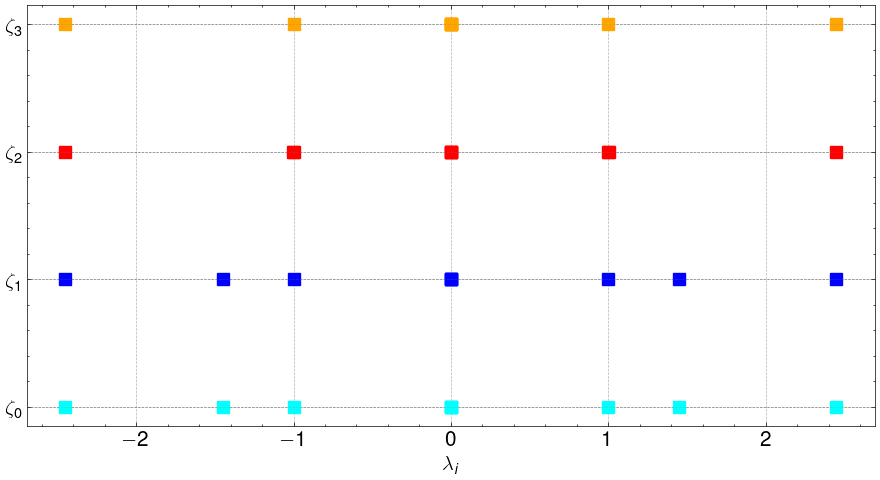

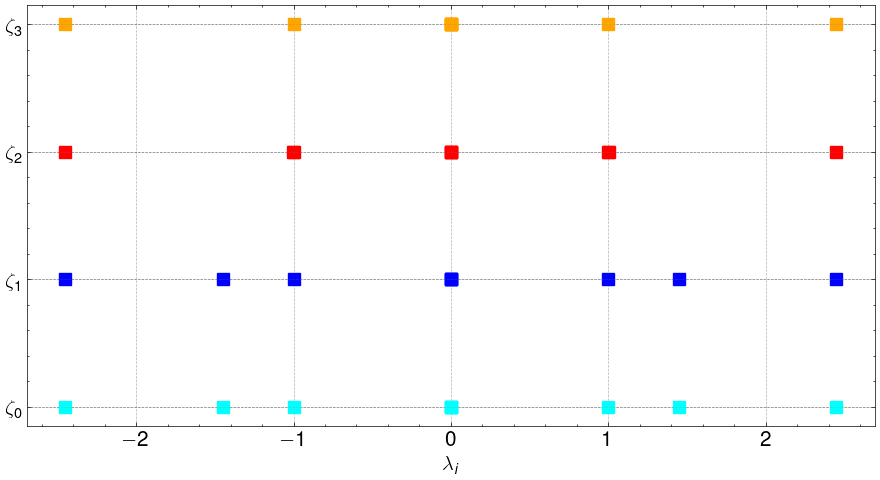

In [130]:
x_dest = -2.0

for Kn in [0.1, 1.0]:
    eigenvalues = []
    for anglepair in range(n_angle_pairs):
        file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
        data = pd.read_csv(file(anglepair))

        x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
        lambda_values_string = data['eigenvalue'][x_idx]
        lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
        eigenvalues.append(lambda_values)

        print(f'Eigenvalues: {lambda_values}')

    angles = [
        (eigenvalues[0], 'cyan', '$\\zeta_0$'),
        (eigenvalues[1], 'blue', '$\\zeta_1$'),
        (eigenvalues[2], 'red', '$\\zeta_2$'),
        (eigenvalues[3], 'orange', '$\\zeta_3$')
    ]

    fig, axs = plt.subplots()

    for i, (lambda_values, color, label) in enumerate(angles):
        # Plot the eigenvalues as points at height 'i'
        axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
        
        # Add a faint horizontal line to guide the eye for each category
        axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    axs.tick_params(axis='x', labelsize=15)
    axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

    axs.set_xlabel('$\\lambda_i$', fontsize=15)
    # axs.set_ylabel('Closure Model')
    axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

    fig.tight_layout()
    # fig.savefig('../out/Figures/1D3D/Eigenvalues_Equilibrium.pdf')
    fig.show()

Eigenvalues: [-2.236907252689489, -1.21121745278958, -0.7732414300198379, 0.2075870046969186, 0.21303540829518886, 0.21303540829518886, 0.23788608381293014, 1.1314566608128482, 1.5810559342228458, 2.5363443246418647]
Eigenvalues: [-2.2368684394755065, -1.2122181904062825, -0.7732224195155188, 0.21332582467170624, 0.215078447345449, 0.215078447345449, 0.2378899955773669, 1.1314711220238076, 1.580892374334275, 2.536351808566157]
Eigenvalues: [-2.2397158757700923, -0.7957053859160872, -0.7743639701267683, 0.22660337010106787, 0.23167365530863204, 0.23167365530863204, 0.2366240006120866, 1.1278074701122618, 1.1569787849563946, 2.5332574686477174]
Eigenvalues: [-2.2877287557045656, -0.7661342120295582, -0.56150278294948, 0.22837642946965456, 0.2550689888686405, 0.36002070848233686, 0.9917074138567745, 0.9917074138567745, 1.0066081183636473, 2.7088597736824602]


/tmp/ipykernel_16641/3279054937.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Eigenvalues: [-2.2598062186974697, -0.9517039220911654, -0.5328739809414502, 0.4551969725596905, 0.47269854588608967, 0.47269854588608967, 0.5616274284734701, 1.2363514549311916, 1.7195479295294342, 2.7533955375996824]
Eigenvalues: [-2.2597342000507505, -0.9650504725077431, -0.5328291520095173, 0.4692452550969506, 0.4749141913841757, 0.4749141913841757, 0.5616392822134084, 1.2363778536991301, 1.723195051023948, 2.7534184995227453]
Eigenvalues: [-2.2558928015911635, -0.5721058647915435, -0.5310743427169519, 0.561399317861791, 0.5865280564906301, 0.5865280564906301, 0.6251465444885975, 1.2362726192275417, 1.357835200197569, 2.7522916808572044]
Eigenvalues: [-2.3677069765769083, -0.5203775680849438, -0.24370224711278518, 0.5105516901086126, 0.5441263142867305, 0.703290405270426, 1.1775202057133076, 1.3823446830490838, 1.3823446830490838, 3.068608831283387]


/tmp/ipykernel_16641/3279054937.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


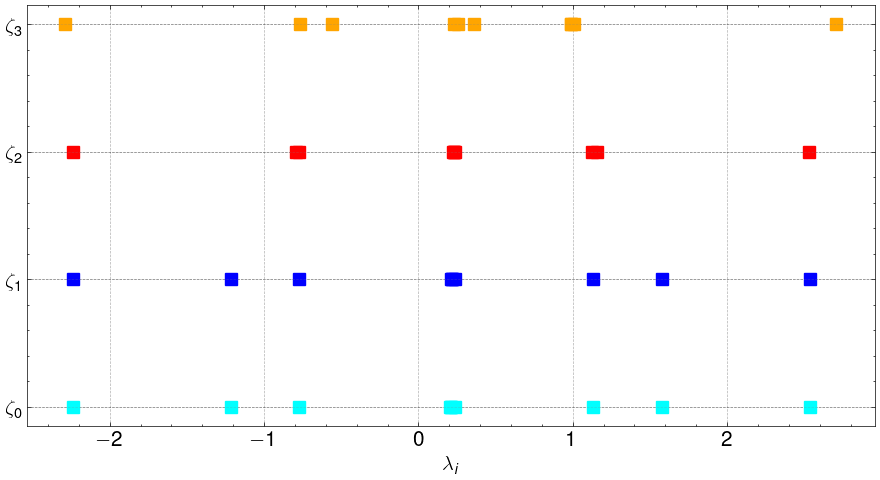

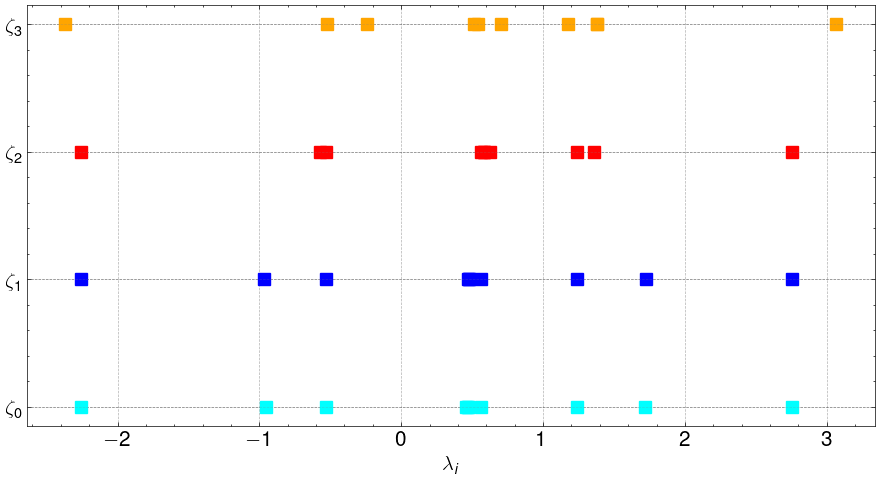

In [131]:
x_dest = 0.0

for Kn in [0.1, 1.0]:
    eigenvalues = []
    for anglepair in range(n_angle_pairs):
        file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
        data = pd.read_csv(file(anglepair))

        x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
        lambda_values_string = data['eigenvalue'][x_idx]
        lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
        eigenvalues.append(lambda_values)

        print(f'Eigenvalues: {lambda_values}')

    angles = [
        (eigenvalues[0], 'cyan', '$\\zeta_0$'),
        (eigenvalues[1], 'blue', '$\\zeta_1$'),
        (eigenvalues[2], 'red', '$\\zeta_2$'),
        (eigenvalues[3], 'orange', '$\\zeta_3$')
    ]

    fig, axs = plt.subplots()

    for i, (lambda_values, color, label) in enumerate(angles):
        # Plot the eigenvalues as points at height 'i'
        axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
        
        # Add a faint horizontal line to guide the eye for each category
        axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    axs.tick_params(axis='x', labelsize=15)
    axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

    axs.set_xlabel('$\\lambda_i$', fontsize=15)
    # axs.set_ylabel('Closure Model')
    axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

    fig.tight_layout()
    # fig.savefig('../out/Figures/1D3D/Eigenvalues_Shock.pdf')
    fig.show()